In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Downloads/proj3_ecommerce_cleaned_new.csv",index_col=False) #index없이 불러오기

In [3]:
df.head()

,Unnamed: 0,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,...,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Credit_Group
0,0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,...,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1,Middle
1,1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,...,7.0,3.0,0.0,23.3,3.0,1067.47,3028.0,0,Q4,High
2,2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,...,4.0,1.0,0.0,8.8,2.0,1289.75,2317.0,0,Q4,Middle
3,3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,...,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1,High
4,4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,...,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44593 entries, 0 to 44592
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     44593 non-null  int64  
 1   Age                            44593 non-null  float64
 2   Gender                         44593 non-null  object 
 3   Country                        44593 non-null  object 
 4   City                           44593 non-null  object 
 5   Membership_Years               44593 non-null  float64
 6   Login_Frequency                44593 non-null  float64
 7   Session_Duration_Avg           44593 non-null  float64
 8   Pages_Per_Session              44593 non-null  float64
 9   Cart_Abandonment_Rate          44593 non-null  float64
 10  Wishlist_Items                 44593 non-null  float64
 11  Total_Purchases                44593 non-null  float64
 12  Average_Order_Value            44593 non-null 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,44593.0,24981.092503,14439.509790,0.00,12506.00,24963.000000,37519.00,49999.000000
Age,44593.0,37.777970,11.444548,18.00,29.00,38.000000,46.00,75.000000
Membership_Years,44593.0,2.978942,2.059064,0.10,1.40,2.500000,4.00,10.000000
Login_Frequency,44593.0,11.639181,7.815523,0.00,6.00,11.000000,17.00,46.000000
Session_Duration_Avg,44593.0,27.690582,10.496367,1.00,20.30,27.679433,34.10,75.600000
Pages_Per_Session,44593.0,8.730334,3.663209,1.00,6.20,8.400000,11.00,24.100000
Cart_Abandonment_Rate,44593.0,57.066288,16.278249,0.00,46.40,58.100000,68.70,143.743350
Wishlist_Items,44593.0,3.957101,3.274459,0.00,1.00,3.000000,6.00,28.000000
Total_Purchases,44593.0,13.116985,6.975764,-13.00,8.00,12.000000,17.00,128.700000
Average_Order_Value,44593.0,123.128752,179.521930,26.38,86.98,112.930000,144.46,9666.379178


In [6]:
df.select_dtypes(include=['number']).corr().T

,Unnamed: 0,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
Unnamed: 0,1.000000,-0.000107,-0.000499,-0.001106,0.004562,-0.001130,-0.002307,0.000944,0.004545,-0.000532,...,0.001595,0.001970,-0.003948,0.001500,0.008918,0.003865,-0.004656,0.008746,0.001375,0.004006
Age,-0.000107,1.000000,-0.005345,-0.000988,0.000344,0.004378,0.000117,0.004845,-0.002202,-0.003983,...,-0.013037,0.007332,-0.000625,0.000540,-0.000279,0.004605,0.006184,0.001760,-0.005073,-0.104727
Membership_Years,-0.000499,-0.005345,1.000000,0.002788,0.007265,0.004545,-0.000032,0.004823,-0.022075,-0.000467,...,-0.032304,0.001349,-0.004420,0.006375,0.001625,-0.001315,-0.003717,0.003225,0.007959,-0.000044
Login_Frequency,-0.001106,-0.000988,0.002788,1.000000,0.681710,0.655023,-0.625356,0.539207,0.591713,0.008617,...,0.006516,0.616142,-0.366497,0.498908,0.494125,0.538328,0.005325,0.498177,0.421772,-0.203592
Session_Duration_Avg,0.004562,0.000344,0.007265,0.681710,1.000000,0.710323,-0.672132,0.587598,0.642917,0.001693,...,0.005727,0.647542,-0.394471,0.542131,0.536838,0.585879,0.001275,0.538917,0.456700,-0.216954
Pages_Per_Session,-0.001130,0.004378,0.004545,0.655023,0.710323,1.000000,-0.646871,0.558096,0.612166,0.007290,...,0.002088,0.617923,-0.381676,0.520440,0.512744,0.563180,-0.000622,0.515180,0.441948,-0.224992
Cart_Abandonment_Rate,-0.002307,0.000117,-0.000032,-0.625356,-0.672132,-0.646871,1.000000,-0.535875,-0.580480,-0.004258,...,-0.002467,-0.586689,0.362509,-0.492846,-0.487781,-0.533640,-0.000023,-0.495115,-0.419586,0.275873
Wishlist_Items,0.000944,0.004845,0.004823,0.539207,0.587598,0.558096,-0.535875,1.000000,0.508787,0.001825,...,0.002832,0.511810,-0.307019,0.421168,0.421282,0.464175,0.000972,0.429596,0.358631,-0.176115
Total_Purchases,0.004545,-0.002202,-0.022075,0.591713,0.642917,0.612166,-0.580480,0.508787,1.000000,0.004531,...,0.249100,0.555408,-0.342192,0.465512,0.461886,0.504279,0.005101,0.627590,0.390723,-0.160564
Average_Order_Value,-0.000532,-0.003983,-0.000467,0.008617,0.001693,0.007290,-0.004258,0.001825,0.004531,1.000000,...,0.001380,-0.001445,-0.000662,0.002107,-0.003269,0.000298,0.003722,0.149629,0.002345,0.042590


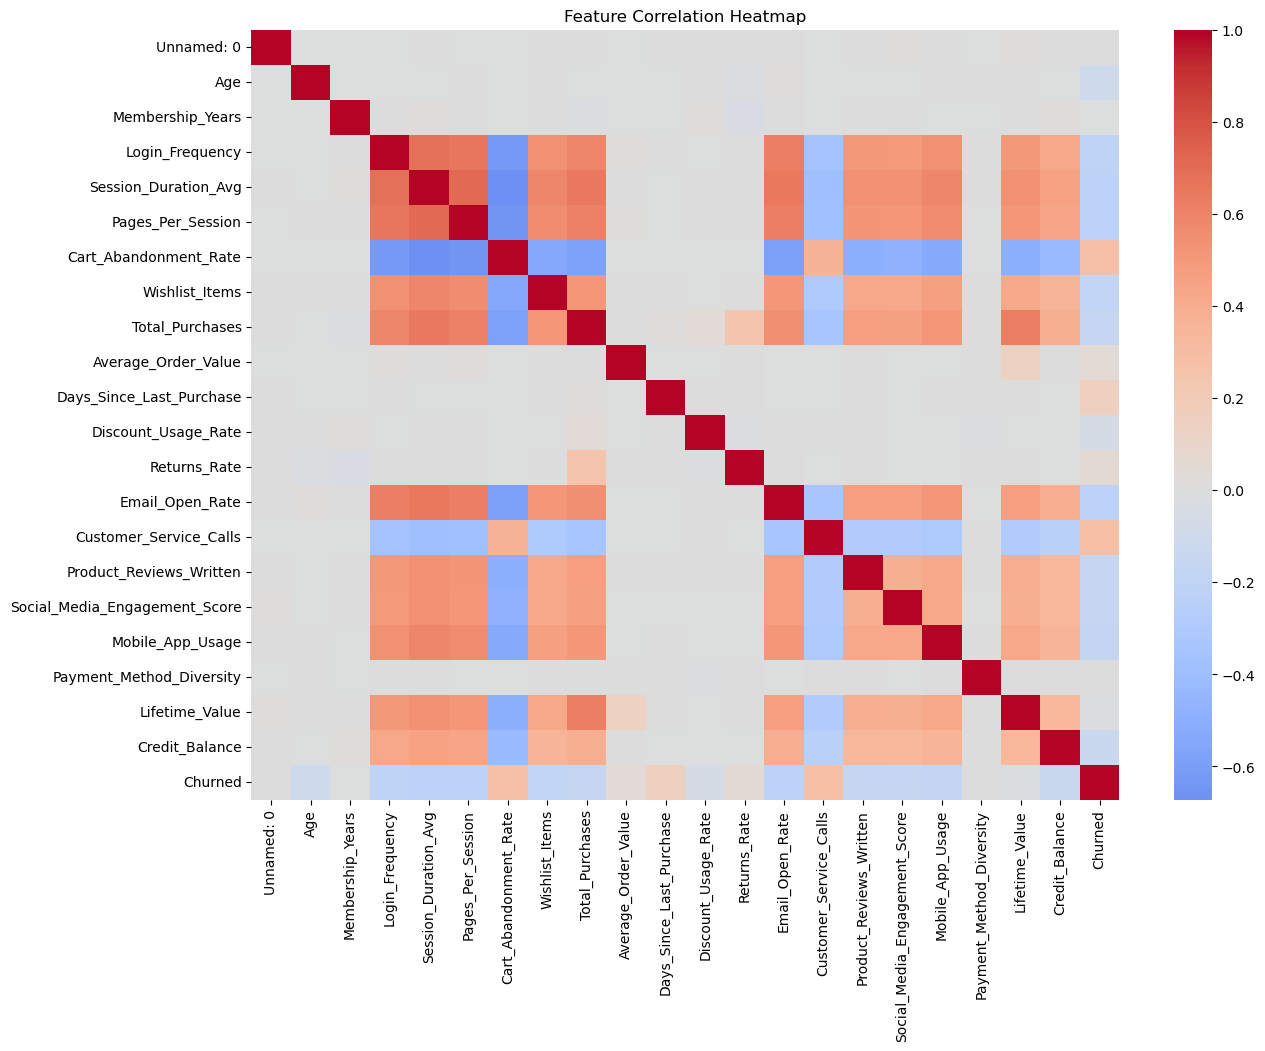

In [7]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()

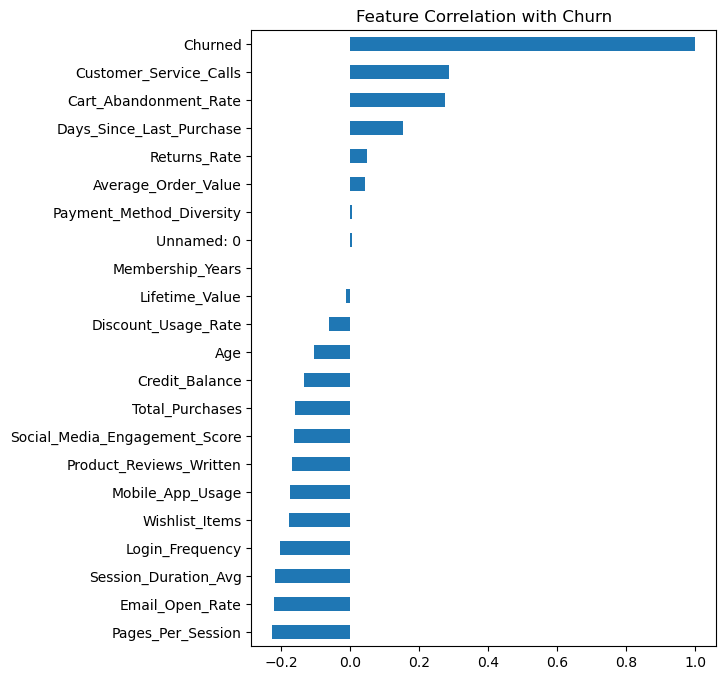

In [8]:
churn_corr = df.select_dtypes(include=['number']).corr()['Churned'].sort_values()

churn_corr.plot(kind='barh', figsize=(6,8))
plt.title("Feature Correlation with Churn")
plt.show()

In [9]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter', 'Credit_Group'],
      dtype='object')

In [10]:
df = df.drop(['Unnamed: 0'], axis=1)

In [11]:
df_dummies = pd.get_dummies(df, drop_first=True)
print(df_dummies)

        Age  Membership_Years  Login_Frequency  Session_Duration_Avg  \
0      43.0               2.9             14.0                  27.4   
1      36.0               1.6             15.0                  42.7   
2      45.0               2.9             10.0                  24.8   
3      56.0               2.6             10.0                  38.4   
4      35.0               3.1             29.0                  51.4   
...     ...               ...              ...                   ...   
44588  38.0              10.0             10.0                  35.8   
44589  37.0               1.4             21.0                  32.4   
44590  44.0               2.8             19.0                  40.3   
44591  41.0               2.9             17.0                  29.9   
44592  56.0               2.2              2.0                  18.2   

       Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  \
0                    6.0                   50.6             3.0   
1

In [12]:
corr_matrix = df_dummies.corr()

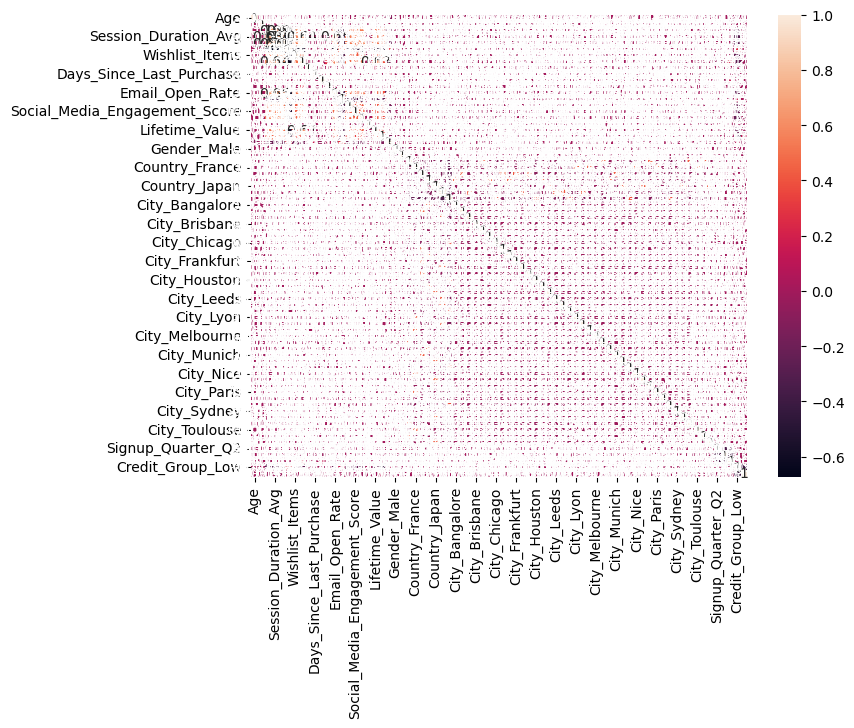

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)

plt.savefig('Downloads/corr_graph22.png')
plt.show()

In [15]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [16]:
y_column = ['Churned']
X = df_dummies.drop(y_column, axis=1)
y = df_dummies[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [17]:
# XGBClassifier
XGBmodel = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)


XGBmodel.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [18]:
y_pred = XGBmodel.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9215158650072878


<Figure size 1000x600 with 0 Axes>

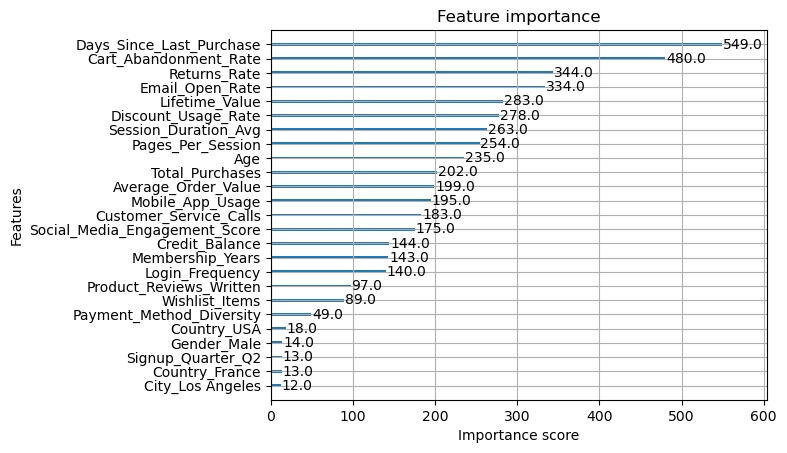

In [28]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(XGBmodel,max_num_features=25)

plt.savefig('Downloads/feature_22.png', bbox_inches='tight')

plt.show()